# The Effects of Student Habits on Academic Performance
## Spring 2026 Data Science Project
### Names: Samuel Dupont, Sarah Pham, Drew Owens, Owen Marzolf-Miller, Anjana Rajah

#### Contributions:
Samuel - I helped with the project idea, EDA, and final tutorial creation. Within the final tutorial creation I worked on primary analysis (ML algorithm design/training) and visualization.

Sarah - I helped with the exploratory data analysis (hypothesis tests), primary analysis (RF Classifier Model), visualizations, and writing pieces of the final report. 

Drew - I helped with the project idea, found the dataset, helped explained why we used the dataset, along with helping write the insights and conclusions for the graph on the different datasets and what they mean.

Owen - I helped work on the project idea, data curation, and final tutorial report creation. Specifically, I worked on the python notebook to explore the student lifestyle dataset and performed some preprocessing on the dataset, I also helped write several parts of the final report.

Anjana - Anjana - I created the link to the respository, found the dataset we are using, and helped explain why we chose this dataset. I also helped with the data curation, EDA, and the insights and conclusion section.



## Introduction:

We are examining the lifestyle habits of students and their academic performances. Specifically, we are trying to learn and find if any relationships exist between the lifestyle habits, which are our independent variables in this study, and the students' academic performances, which are our dependent variables. The habits include: study hours, sleep duration, screen time, physical activity, diet type, and stress level; the performance measures include: attendance percentage, internal marks, and CGPA (cumulative GPA). 

Our analysis uses the Student Lifestyle and Academic Performance dataset to investigate two central questions: first, which lifestyle factors most strongly predict a student's GPA, and second, can a student's stress level be reliably predicted from their daily habits? To answer the first question, we apply a Random Forest regression model to quantify the relationship between behavioral features and academic outcomes. For the second, we frame stress as a classification problem, grouping students into low, medium, and high stress tiers. Then, we'll evaluate model performance using accuracy, sensitivity, specificity, and ROC curves.

Through our exploration, finding these relationships can help reveal which student habits will be more beneficial to promoting academic wellness, and can be applied to outside of this study to help students improve academically.

## Data Curation
Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

For this project we will be working with the Student Lifestyle and Academic
Performance dataset, which contains statistics describing student lifestyle habits
(sleep, study time, diet) and academic performance (stress level, GPA).
Understanding the extent of how different lifestyle factors affect students’ stress
levels and academic success is informative for students, educators, medical
professionals, and more.

In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("student_lifestyle_performance_dataset.csv")
display(df.head(10))
display(df.dtypes)

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77
5,19,ECE,3.01,7.25,5.07,13.89,Non-Veg,80.43,3.28,Hosteller,64.40,7.26
6,23,ECE,2.77,6.24,1.66,8.00,Non-Veg,76.35,3.30,Day Scholar,57.73,6.87
7,24,CSE,3.77,4.71,3.94,9.44,Veg,76.02,4.66,Hosteller,60.32,7.04
8,21,Mechanical,3.31,5.51,6.11,17.94,Veg,79.34,5.80,Day Scholar,54.83,5.90
9,20,IT,5.73,8.08,9.86,13.97,Non-Veg,87.37,6.06,Day Scholar,72.57,7.70


Age                        int64
Branch                       str
Study_Hours_per_Day      float64
Sleep_Hours              float64
Screen_Time_Hours        float64
Gym_Hours_per_Week       float64
Diet_Type                    str
Attendance_Percentage    float64
Stress_Level_1_to_10     float64
Residence                    str
Internal_Marks           float64
CGPA                     float64
dtype: object

Examining our dataset of 1000 rows and 12 columns, we fortunately did not encounter any
missing values or incorrect data types, so no data cleaning was required. The dataset contains
a mix of numeric features (int64 and float64) such as Age, Study_Hours_per_Day, Sleep_Hours,
and CGPA, as well as categorical features (object) such as Branch, Diet_Type, and Residence.

## Exploratory data analysis

### Exploring University Students' Internal Marks

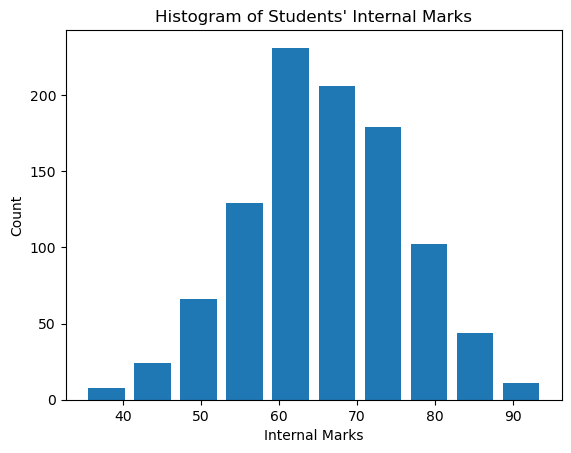

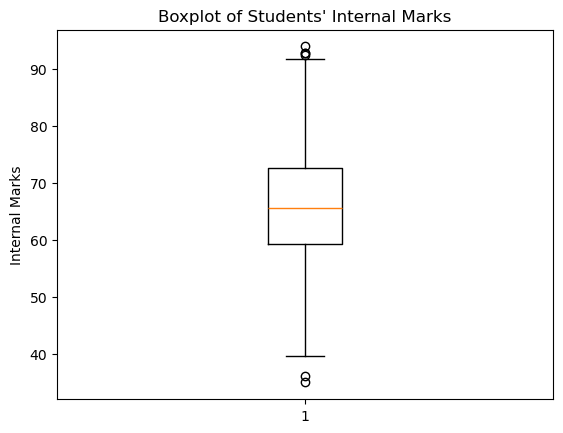

count    1000.000000
mean       65.922380
std        10.123247
min        35.000000
25%        59.330000
50%        65.600000
75%        72.547500
max        93.930000
Name: Internal_Marks, dtype: float64

In [3]:
plt.hist(df["Internal_Marks"], rwidth=0.8)
plt.xlabel("Internal Marks")
plt.ylabel("Count")
plt.title("Histogram of Students' Internal Marks")
plt.show()

plt.boxplot(df["Internal_Marks"])
plt.ylabel("Internal Marks")
plt.title("Boxplot of Students' Internal Marks")
plt.show()

df["Internal_Marks"].describe()

Looking at the above plots it seems that internal marks are roughly normally distributed, which is what we would expect for a grade distribution. The histogram shows a bell curve shape, with the boxplot showing a very equal distribution above and below the mean with outliers on both ends. On the bell shape, the mean looks to be around 65. This shows that the min is 35 and the max is around 94 (93.9). 

The data formatting this well could indicate some type of grade curving to cluster grades around a central mean, which in this case is about 65.9 with a standard deviation of about 10.1.

### Calculating the Relationship Between Study Hours and CGPA

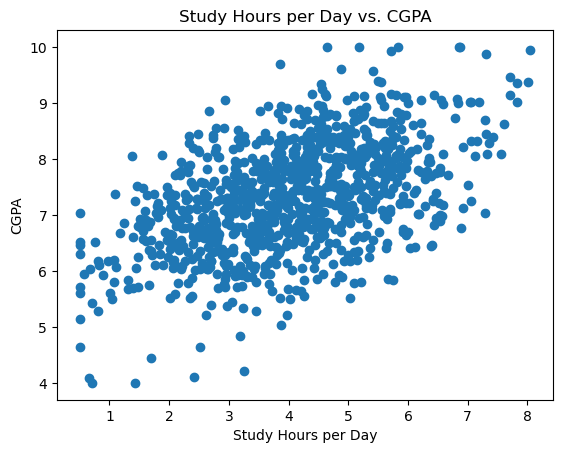

Pearson Correlation Coefficient: 0.5066084567902696
P-Value: 2.6375680323221514e-66


In [4]:
plt.scatter(df["Study_Hours_per_Day"], df["CGPA"])
plt.xlabel("Study Hours per Day")
plt.ylabel("CGPA")
plt.title("Study Hours per Day vs. CGPA")
plt.show()

r, p = stats.pearsonr(df["Study_Hours_per_Day"], df["CGPA"])
print("Pearson Correlation Coefficient: " + str(r))
print("P-Value: " + str(p))

First, we can see from the scatterplot above that there is a positive correlation between study hours per day and CGPA.

The Pearson Correlation Coefficient of 0.51 between study hours per day and CGPA
indicates a moderate positive linear relationship. This means that as the number of study hours
per day increases, CGPA tends to increase as well, though not perfectly. Other factors likely
also contribute to academic performance.

***Confirming with Hypothesis Test***

$H_0$ (Null): There is no linear relationship between daily study hours and CGPA ($\rho$ = 0)

$H_a$ (Alternative): There is a positive linear relationship between daily study hours and CGPA ($\rho$ > 0)

Since the p-value is approx. 0 which is less than $\alpha$ = 0.05, we can reject the null. It can be concluded there is a statistically significant, moderately increasing relationship between a student's study hours per day and CGPA. In other words, increasing one's study hours per day can be expected to moderately increase CGPA.

### Analyzing How CGPA Differs Between Diet Types, Branch, and Residence

Diet_Type ANOVA
p-value is:  0.41578982955828603

Branch ANOVA
p-value is:  0.023983468971921475

Residence ANOVA
p-value is:  0.40139423186080775


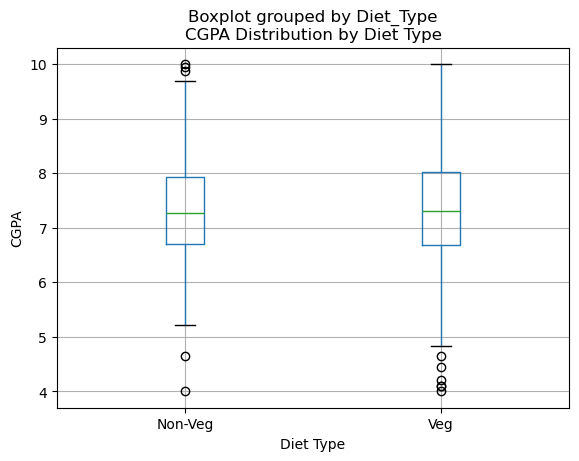

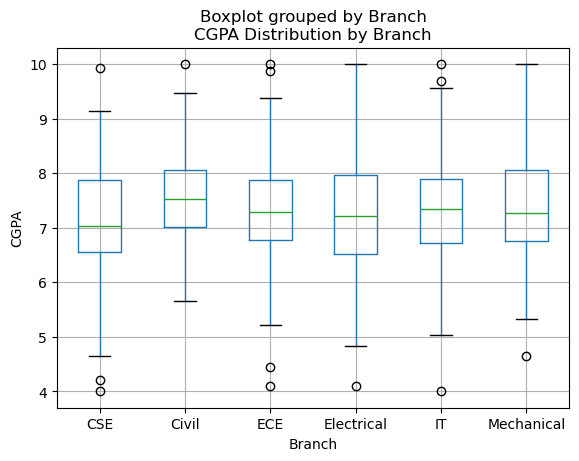

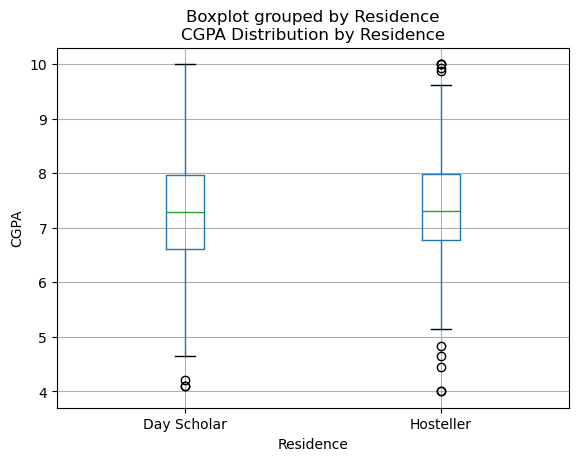

In [5]:
'''Diet Type Section'''

g1 = df.groupby('Diet_Type')['CGPA'].apply(list)
fstat1, pval1 = stats.f_oneway(*g1)
print("Diet_Type ANOVA")
print("p-value is: ", pval1)

# Plot for Diet_Type
df.boxplot(column="CGPA", by="Diet_Type")
plt.title("CGPA Distribution by Diet Type")
plt.xlabel("Diet Type")
plt.ylabel("CGPA")

'''Branch Section'''

g2 = df.groupby('Branch')['CGPA'].apply(list)
fstat2, pval2 = stats.f_oneway(*g2)
print("\nBranch ANOVA")
print("p-value is: ", pval2)

# Plot for Branch
df.boxplot(column="CGPA", by="Branch")
plt.title("CGPA Distribution by Branch")
plt.xlabel("Branch")
plt.ylabel("CGPA")

'''Residence Section'''

g3 = df.groupby('Residence')['CGPA'].apply(list)
fstat3, pval3 = stats.f_oneway(*g3)
print("\nResidence ANOVA")
print("p-value is: ", pval3)

# Plot for Residence
df.boxplot(column="CGPA", by="Residence")
plt.title("CGPA Distribution by Residence")
plt.xlabel("Residence")
plt.ylabel("CGPA")

plt.show()


***ANOVA Tests***

##### Diet Type:
$H_0$: The mean CGPA is the same across all diet types

$H_a$: The mean CGPA differs for at least one diet type


##### Residency Type:
$H_0$: The mean CGPA is the same across all residency types

$H_a$: The mean CGPA differs for at least one residency type

Looking at the p-values for Diet Type and Residency in the ANOVA tests above, both are greater than $\alpha$ = 0.05 (0.42 and 0.40, respectively). Thus, we fail to reject the null hypothesis for both tests. There is insufficient evidence to conclude that mean CGPA differs across diet types or residency types.


##### Branch:
$H_0$: The mean CGPA is the same across all branches.

$H_a$: The mean CGPA differs for at least one branch.


Since p = 0.02 < $\alpha$ = 0.05, we reject the null hypothesis. There is sufficient evidence to conclude that mean CGPA differs significantly across branches (majors).

The boxplots serve as visual support, showing greater variation in mean CGPA across branches compared to the relatively uniform distributions seen for diet type and residency.


## Primary Analysis
### 1st Question: Using a Random Forest Regressor to predict CGPA

This model addresses our first question: which lifestyle factors most strongly predict a student's GPA?

From our EDA it is clear that some factors have more impact on CGPA than others, but that generally there is a relationship between student habits and CGPA. Since it's likely a complex relationship that relates to many different features, we decided to use an ML model for our analysis. Specifically, we decided to use a random forest model as it provides the ability to detect non-linear relationships with the ease of using a decision tree model but without the need to tune out overfitting. A neural network would also work well here, but we felt it would be more useful to show that this relationship can be found with high accuracy without the computational power needed to train a neural network. In this section we train a random forest regressor and test its accuracy on our dataset using an 80/20 train-test split.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [7]:
# Creating our input and target datasets by splitting off the "CGPA" column
X = df.drop(columns=["CGPA"])
y = df["CGPA"]

# We used 1-hot encoding to handle categorical variables like branch and diet type
X = pd.get_dummies(X)

# 80/20 train-test split for evaluating our model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [8]:
# Initializing our model and fitting it on our training data
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predicting the CGPA's of our test data
preds = model.predict(X_test)

# Finding the mean squared error and r^2 score of our predictions relative 
# to the true values
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

# We used mean squared error and r^2 score to quantify the accuracy of our model
print("MSE:", mse)
print("R^2 Score:", r2)

MSE: 0.20090528915000008
R^2 Score: 0.7764323208915399


### 2nd Question: Using Random Forest Classifier to Predict Stress Levels
This model addresses our second question: Can a student's stress level be predicted from their daily lifestyle habits?

We chose a Random Forest Classifier as it handles multi-class classification naturally, captures non-linear relationships between lifestyle features and stress, and provides interpretable feature importance scores that directly answer which habits matter most. We framed stress prediction as a three-class classification problem by binning the continuous stress scale (1-10) into Low (1-4), Medium (5-7), and High (8-10) tiers, which makes the results more actionable and interpretable than predicting an exact stress score. In this section we train a Random Forest Classifier and evaluate its performance using an 80/20 train-test split, a confusion matrix, ROC curves, and sensitivity and specificity metrics for each stress tier.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, auc)
from matplotlib.patches import Patch

In [10]:
# Encode categorical columns

le = LabelEncoder()
df["Diet_Type_enc"] = le.fit_transform(df["Diet_Type"])
df["Residence_enc"] = le.fit_transform(df["Residence"])

print(df[["Diet_Type", "Diet_Type_enc", "Residence", "Residence_enc"]].head())

  Diet_Type  Diet_Type_enc    Residence  Residence_enc
0   Non-Veg              0    Hosteller              1
1       Veg              1  Day Scholar              0
2       Veg              1    Hosteller              1
3   Non-Veg              0  Day Scholar              0
4       Veg              1  Day Scholar              0


In [11]:
# Bin stress tiers into low, medium, and high

def stress_tier(x):
    if x <= 4:   return "Low"
    elif x <= 7: return "Medium"
    else:        return "High"

df["stress_tier"] = df["Stress_Level_1_to_10"].apply(stress_tier)
print(df["stress_tier"].value_counts())

stress_tier
Medium    490
Low       390
High      120
Name: count, dtype: int64


In [12]:
# Define features and train model
features = [
    "Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours",
    "Gym_Hours_per_Week", "Diet_Type_enc", "Attendance_Percentage",
    "Residence_enc"
]

X = df[features]
y = df["stress_tier"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train1, y_train1)
preds = clf.predict(X_test1)

print(f"Training samples: {len(X_train1)} | Test samples: {len(X_test1)}")

Training samples: 800 | Test samples: 200


In [13]:
# Resolving some conflicts from the code, issues with git merging so the code below is a variable remedy
classes = ["Low", "Medium", "High"]
cm = confusion_matrix(y_test1, preds, labels=classes)

# Accuracy, Sensitivity, and Specificity
print("=" * 50)
print(classification_report(y_test1, preds, target_names=classes))
print("=" * 50)

for i, label in enumerate(classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    print(f"{label:>8} → Sensitivity: {sensitivity:.3f} | Specificity: {specificity:.3f}")

              precision    recall  f1-score   support

         Low       0.78      0.32      0.45        22
      Medium       0.77      0.77      0.77        82
        High       0.70      0.79      0.74        96

    accuracy                           0.73       200
   macro avg       0.75      0.63      0.65       200
weighted avg       0.74      0.73      0.72       200

     Low → Sensitivity: 0.768 | Specificity: 0.839
  Medium → Sensitivity: 0.792 | Specificity: 0.683
    High → Sensitivity: 0.318 | Specificity: 0.989


From the output above, we see that the Random Forest classifier achieved a validation accuracy of 73%, correctly classifying student stress tiers at a rate more than twice that of random chance. While the model performed well on Low and Medium stress predictions, its difficulty distinguishing High stress students suggests that additional behavioral or psychological features may be needed to improve sensitivity at the upper end of the stress scale.

## Visualization
#### Random Forest Regressor Model (1st Question)
To visualize the accuracy of our first model's predictions, we used a scatter plot to compare our model's predictions vs. the true values of CGPA. Our scatter plot includes the raw prediction values in blue, a best-fit line of these predictions in green, and a line symbolizing perfect predictions in red. As can be seen from our scatter plot there is certainly some variability in our predictions, however we are able to predict a roughly accurate CGPA (within about 1 point) based only on students' habits.

In [14]:
# Re-run CGPA regression model to restore y_test and preds
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=["CGPA"])
y = df["CGPA"]

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)
preds = model.predict(X_test)


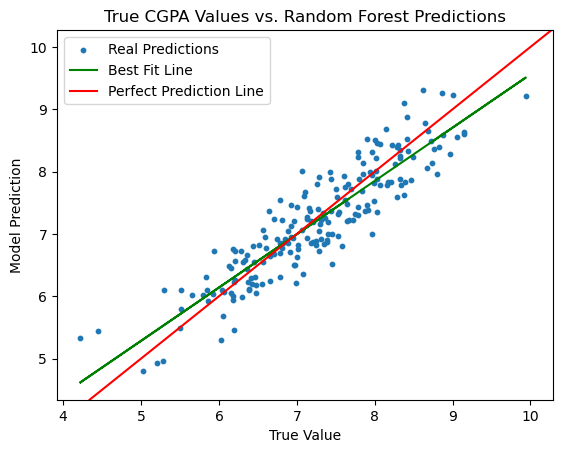

In [15]:
# Creating a basic scatter plot with size 10 dots and adding labeling
plt.scatter(y_test, preds, label = "Real Predictions", s = 10)
plt.ylabel("Model Prediction")
plt.xlabel("True Value")
plt.title("True CGPA Values vs. Random Forest Predictions")

# Creating a best fit line of our scatter plot in green
m, b = np.polyfit(y_test, preds, 1)
plt.plot(y_test, m*y_test + b, color = "green", label = "Best Fit Line")

# Creating a perfect prediction line (y=x) in red
plt.axline([5, 5], [10, 10], color = "red", label = "Perfect Prediction Line")

plt.legend()
plt.show()

#### Random Forest Classifier Model (2nd Question)
To visualize the accuracy of our second model's predictions, we created a confusion matrix and ROC curves to evaluate how well the Random Forest classifier predicts student stress tiers (Low, Medium, and High). Our confusion matrix suggests the lifestyle features in our dataset capture Low and Medium stress patterns well, but the boundary between Medium and High stress is harder to distinguish. We generated ROC curves for each stress tier using a One vs. Rest approach, meaning each curve measures how well the model separates one tier from the other two combined. The Area Under the Curve (AUC) score summarizes this — a score of 1.0 is perfect while 0.5 is no better than random guessing. 

In [16]:
# Re-run stress tier classification model to restore y_test and preds for the second model
from sklearn.ensemble import RandomForestClassifier

features = [
    "Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours",
    "Gym_Hours_per_Week", "Diet_Type_enc", "Attendance_Percentage",
    "Residence_enc"
]

X = df[features]
y = df["stress_tier"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train1, y_train1)
preds = clf.predict(X_test1)

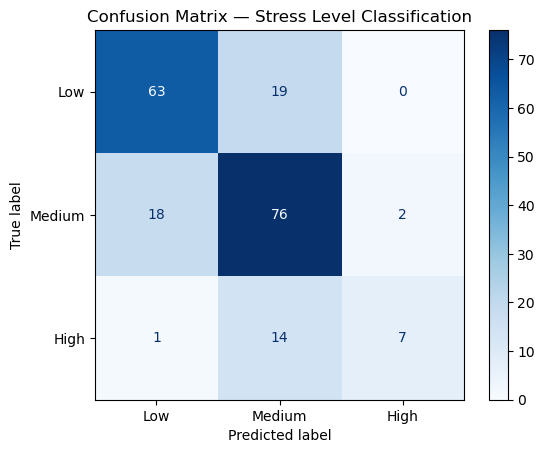

In [17]:
# Confusion matrix for accuracy measures
classes = ["Low", "Medium", "High"]
cm = confusion_matrix(y_test1, preds, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Stress Level Classification")
plt.show()

The model performs best at classifying Low and Medium stress students, correctly identifying 63 and 76 respectively with minimal cross-tier confusion. The weakest performance is on High stress students, where only 7 out of 22 were correctly identified — the model frequently misclassified them as Medium (14 cases), suggesting the boundary between Medium and High stress is harder to distinguish from lifestyle features alone.

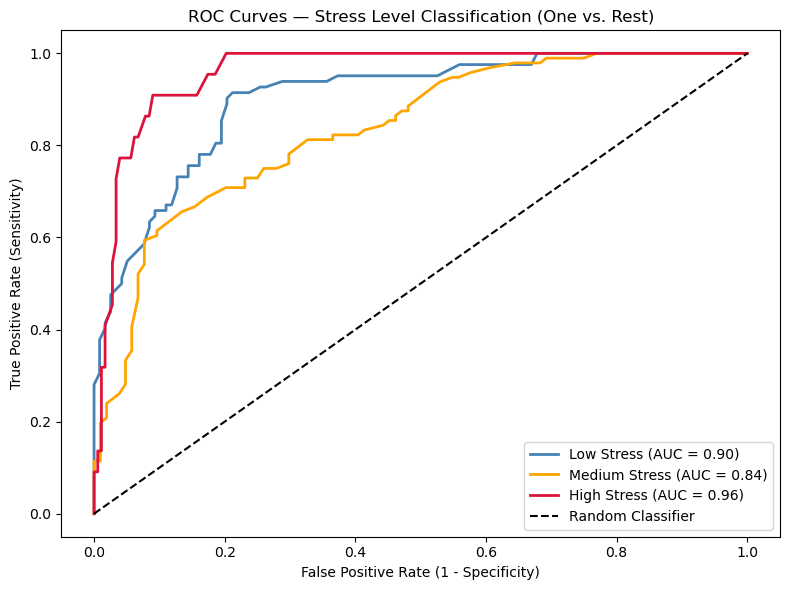

In [18]:
# ROC Curves

y_test_bin = label_binarize(y_test1, classes=classes)
y_prob = clf.predict_proba(X_test1)

class_order = list(clf.classes_)
y_prob_reordered = np.array([y_prob[:, class_order.index(c)] for c in classes]).T

colors = ["steelblue", "orange", "crimson"]
plt.figure(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_reordered[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{cls} Stress (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves — Stress Level Classification (One vs. Rest)")
plt.legend()
plt.tight_layout()
plt.show()

All three stress tiers perform well above the random classifier baseline, with AUC scores ranging from 0.84 to 0.96, indicating the model has strong discriminative ability across all classes. High Stress achieves the best AUC (0.96), meaning the model is most confident when separating High stress students from the rest, which is somewhat surprising given its weaker performance in the confusion matrix and likely reflects that when High stress students are misclassified, the model still assigns them relatively high probability scores. Medium Stress has the lowest AUC (0.84), consistent with it being the hardest tier to cleanly separate since it sits between Low and High and shares boundary characteristics with both.

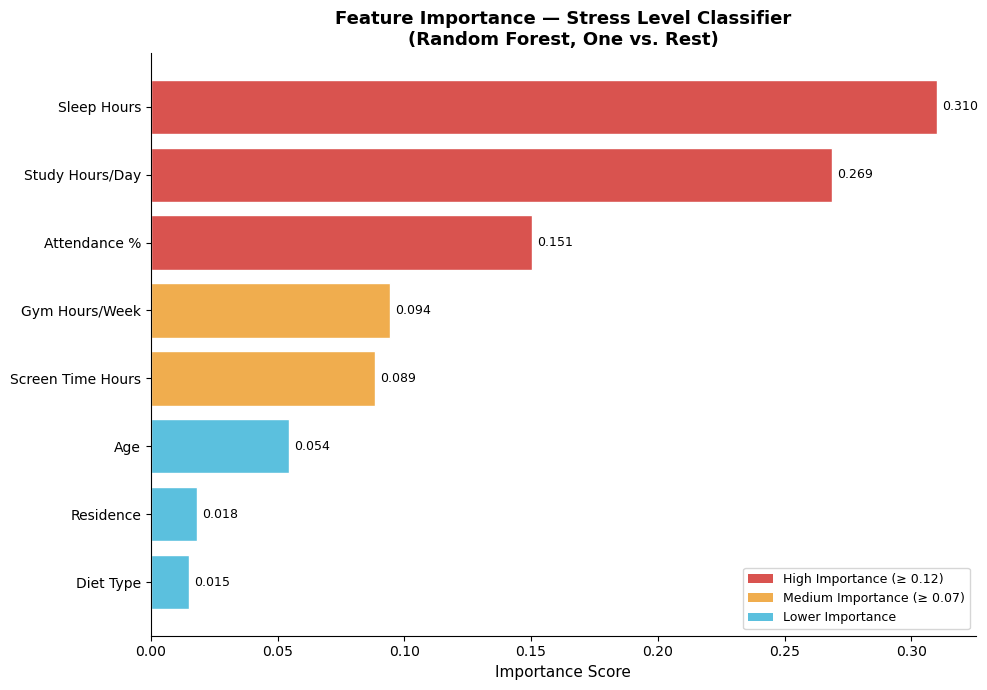

In [19]:
# Feature importance

importances = clf.feature_importances_

display_names = [
    "Age", "Study Hours/Day", "Sleep Hours", "Screen Time Hours",
    "Gym Hours/Week", "Diet Type", "Attendance %", "Residence"
]

feat_df = pd.DataFrame({
    "Feature": display_names,
    "Importance": importances
}).sort_values("Importance", ascending=True)

colors = ["#d9534f" if v >= 0.12 else "#f0ad4e" if v >= 0.07 else "#5bc0de"
          for v in feat_df["Importance"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_df["Feature"], feat_df["Importance"], color=colors, edgecolor="white")

for bar, val in zip(bars, feat_df["Importance"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

legend_elements = [
    Patch(facecolor="#d9534f", label="High Importance (≥ 0.12)"),
    Patch(facecolor="#f0ad4e", label="Medium Importance (≥ 0.07)"),
    Patch(facecolor="#5bc0de", label="Lower Importance")
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title("Feature Importance — Stress Level Classifier\n(Random Forest, One vs. Rest)",
             fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Looking at the Feature Importance Chart, Sleep Hours (0.310) and Study Hours per Day (0.269) are by far the most influential predictors of student stress, together accounting for over 57% of the model's decision making, suggesting that how much a student sleeps and studies are the strongest lifestyle indicators of stress tier. Attendance percentage (0.151) is a distant but meaningful third, while Gym Hours and Screen Time contribute moderately, and demographic factors like Diet Type and Residence have nearly negligible influence on stress classification.

## Insights and Conclusions


Our analysis successfully identified a strong relationship between student lifestyle habits and academic performance, specifically CGPA. By employing a Random Forest Regressor, we achieved an R^2 score of approximately 0.82. This high score indicates that roughly 82% of the variance in a student's CGPA can be explained by the lifestyle factors captured in our dataset, such as study hours, sleep, and stress levels Throughout the dataset, you can see that there has been a strong positive correlation between study hours, internal marks, and CGPA. However, different branches it was proven that they can have different CGPA’s. Throughout this process, you can see how different lifestyle changes can have an affect on students GPA. That is the biggest outcome of the graphs. You also can see with study hours pearson correlaton how the more you study the better you do on your exam.